# processing zecmip data

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
# import matplotlib.pyplot as plt
# from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
# import matplotlib as mpl
# import matplotlib.ticker as mticker
import netCDF4
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from cartopy.util import add_cyclic_point
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
# from dask.distributed import Client
# client = Client(n_workers=4, threads_per_worker=2)
# client

In [4]:
from scipy import stats

In [5]:
# mpl.rcParams['font.family'] = 'Droid Sans'
# mpl.rcParams['font.size'] = 12
# # Edit axes parameters
# mpl.rcParams['axes.linewidth'] = 1.5
# # Tick properties
# mpl.rcParams['xtick.major.size'] = 5
# mpl.rcParams['xtick.minor.size'] = 3
# mpl.rcParams['xtick.major.width'] = 1
# mpl.rcParams['xtick.direction'] = 'out'
# mpl.rcParams['ytick.major.size'] = 5
# mpl.rcParams['ytick.minor.size'] = 3
# mpl.rcParams['ytick.major.width'] = 1
# mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [6]:
from functions import preproc_funcs as funcs

In [7]:
from functions import xr_lowess

In [8]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [9]:
import glob
import multiprocessing as mp

In [ ]:
models_zec = [
    'ACCESS-ESM1-5',
    'CanESM5',
    'CESM2',
    'GFDL-ESM4',
    'GISS-E2-1-G-CC', # 1pctCO2 not present in local directories
    # 'GISS-E2-1-G', # for 1pctCO2 only
    'MIROC-ES2L',
    'MPI-ESM1-2-LR',
    'NorESM2-LM',
    'UKESM1-0-LL',
    'CNRM-ESM2-1'
]

models_zec_co2 = [
    'ACCESS-ESM1-5',
    'CanESM5',
    'CESM2',
    'GFDL-ESM4',
    'GISS-E2-1-G-CC', # 1pctCO2 not present in local directories
    # 'GISS-E2-1-G', # for 1pctCO2 only
    'MIROC-ES2L',
    'MPI-ESM1-2-LR',
    'NorESM2-LM',
    'UKESM1-0-LL',
    # 'CNRM-ESM2-1'
]

In [15]:
# Function to find the first file in each model's r1* directory
def find_all_files(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        # model_identifier = path_parts[7] + '_' + path_parts[9][:-1]
        model_identifier = path_parts[8] + '_' + path_parts[10][:-1]
        if model_identifier not in model_files:
            model_files[model_identifier] = '/'.join(path_parts[:-1]) + '/*.nc'  # Store only the first file for each model
    return model_files


# Function to find the first file in each model's r1* directory
def find_all_files_extended(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        model_identifier = path_parts[8] + '_' + path_parts[10][:-1]
        if model_identifier not in model_files:
            model_files[model_identifier] = '/'.join(path_parts[:-1]) + '/*.nc'  # Store only the first file for each model
    return model_files



## find the files for a single model

In [68]:
model = models_zec[8]
model

'UKESM1-0-LL'

In [69]:
tas_pattern_pic = f'/g/data/*/*/CMIP6/CMIP/*/{model}/piControl/*/Amon/tas/*/*/*.nc'
tas_pattern_1pctCO2 = f'/g/data/*/*/CMIP6/CMIP/*/{model}/1pctCO2/*/Amon/tas/*/*/*.nc'
tas_pattern_brch750 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-750PgC/*/Amon/tas/*/*/*.nc'
tas_pattern_brch1000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-1000PgC/*/Amon/tas/*/*/*.nc'
tas_pattern_brch2000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-2000PgC/*/Amon/tas/*/*/*.nc'

In [70]:
co2_pattern_pic = f'/g/data/*/*/CMIP6/CMIP/*/{model}/piControl/*/Amon/co2/*/*/*.nc'
co2_pattern_1pctCO2 = f'/g/data/*/*/CMIP6/CMIP/*/{model}/1pctCO2/*/Amon/co2/*/*/*.nc'
co2_pattern_brch750 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-750PgC/*/Amon/co2/*/*/*.nc'
co2_pattern_brch1000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-1000PgC/*/Amon/co2/*/*/*.nc'
co2_pattern_brch2000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-2000PgC/*/Amon/co2/*/*/*.nc'

In [71]:
# '/g/data/oi10/replicas/CMIP6/C4MIP/CCCma/CanESM5/esm-1pct-brch-1000PgC/r1i1p2f1/Amon/'

In [72]:
pr_pattern_pic = f'/g/data/*/*/CMIP6/CMIP/*/{model}/piControl/*/Amon/pr/*/*/*.nc'
pr_pattern_1pctCO2 = f'/g/data/*/*/CMIP6/CMIP/*/{model}/1pctCO2/*/Amon/pr/*/*/*.nc'
pr_pattern_brch750 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-750PgC/*/Amon/pr/*/*/*.nc'
pr_pattern_brch1000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-1000PgC/*/Amon/pr/*/*/*.nc'
pr_pattern_brch2000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-2000PgC/*/Amon/pr/*/*/*.nc'



# only for NorESM2 data
pr_pattern_brch1000_day = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-1000PgC/*/day/pr/*/*/*.nc' 

In [73]:

pr_pattern_pic = f'/g/data/*/*/CMIP6/CMIP/*/{model}/piControl/*/Amon/pr/*/*/*.nc'
pr_pattern_1pctCO2 = f'/g/data/*/*/CMIP6/CMIP/*/{model}/1pctCO2/*/Amon/pr/*/*/*.nc'
pr_pattern_brch750 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-750PgC/*/Amon/pr/*/*/*.nc'
pr_pattern_brch1000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-1000PgC/*/Amon/pr/*/*/*.nc'
pr_pattern_brch2000 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-2000PgC/*/Amon/pr/*/*/*.nc'



# only for NorESM2 data
pr_pattern_brch1000_day = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-1pct-brch-1000PgC/*/day/pr/*/*/*.nc' 

In [74]:
tas_files_pic = find_all_files(tas_pattern_pic)
tas_files_1pctCO2 = find_all_files(tas_pattern_1pctCO2)
tas_files_brch750 = find_all_files(tas_pattern_brch750)
tas_files_brch1000 = find_all_files(tas_pattern_brch1000)
tas_files_brch2000 = find_all_files(tas_pattern_brch2000)

In [75]:
co2_files_pic = find_all_files(co2_pattern_pic)
co2_files_1pctCO2 = find_all_files(co2_pattern_1pctCO2)
co2_files_brch750 = find_all_files(co2_pattern_brch750)
co2_files_brch1000 = find_all_files(co2_pattern_brch1000)
co2_files_brch2000 = find_all_files(co2_pattern_brch2000)

In [76]:
pr_files_pic = find_all_files(pr_pattern_pic)
pr_files_1pctCO2 = find_all_files(pr_pattern_1pctCO2)
pr_files_brch750 = find_all_files(pr_pattern_brch750)
pr_files_brch1000 = find_all_files(pr_pattern_brch1000)
pr_files_brch2000 = find_all_files(pr_pattern_brch2000)

pr_files_brch1000_day = find_all_files(pr_pattern_brch1000_day)

In [77]:
co2_files_pic

{}

In [78]:
co2_files_brch1000

{}

In [79]:
co2_files_brch750

{}

In [80]:
co2_files_brch2000

{}

In [81]:
co2_files_1pctCO2

{}

In [82]:
import xesmf as xe

In [83]:
# temp_hist = xr.open_dataset(ts_files_hist['ACCESS-CM2'])
# temp_hist

In [84]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset> Size: 9kB
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 4kB -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0

In [85]:
from dask.diagnostics import ProgressBar

In [47]:
# global_regridder = xe.Regridder(xc.open_mfdataset(uas_files_hist['ACCESS-ESM1-5_r10i1p1f']).load(), ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
# global_regridder

In [48]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_zecmip(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasetas
        var_file = co2_files_brch1000[model_identifier]
        ds_var = xc.open_mfdataset(var_file, use_cftime=True, coords='minimal', compat='override')#.sel(time = slice('1850-01-01', '2015-01-01'))
        # ds_var = xc.open_mfdataset(var_file, use_cftime=True)#.sel(time = slice('1850-01-01', '2015-01-01'))
        # add custom time ranges
        regridder = xe.Regridder(ds_var, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        #
        # with ProgressBar():
        var = regridder(ds_var.co2.resample(time = 'AS-JUN').mean('time')).load()  # var data
        # var = xr.concat([ds_var_hist, ds_var_ssp], dim='time').uas.resample(time = 'AS-JUN').mean('time').load()  # var data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        # var_anom = funcs.calc_anom_annual(var, var.sel(time = slice('1960', '1990')))
        # var_trend = funcs.calc_trend3d(var_anom.sel(time = slice('1980', '2014')), 'time')
        # var_trend_pval = funcs.calc_trend_pval3d(var_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        # weightas = np.cos(np.deg2rad(var.lat))

        # print(f'Completed: {model_identifie}')
        # return model_identifier, var_trend, var_trend_pval, gmst_anom, nino34_index, wp_var, ct_var, so_var
        return model_identifier, var
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")



In [49]:
models_to_process = [(model) for model in co2_files_brch1000 if model in co2_files_brch1000]
models_to_process

['NorESM2-LM_r1i1p1f']

In [50]:
# Run multiprocessing and gather results
res_arr = []
# with mp.Pool(processes=mp.cpu_count()) as pool:
with mp.Pool(processes=4) as pool:
    i = 0
    for res in pool.imap(process_zecmip, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [63]:
model_list = [res_arr[0][0]]
model_list

['NorESM2-LM_r1i1p1f']

In [65]:
model_var = xr.concat([res_arr[0][1]], dim=model_list, coords='minimal', compat='override').rename(dict(concat_dim = 'model')).to_dataset(name = 'co2')

In [66]:
out = xr.merge([model_var])
out

<xarray.Dataset> Size: 221MB
Dimensions:             (plev: 19, time: 101, lon: 240, lat: 120, model: 1)
Coordinates:
  * plev                (plev) float64 152B 1e+05 9.25e+04 ... 500.0 100.0
  * time                (time) object 808B 0066-06-01 00:00:00 ... 0166-06-01...
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
  * model               (model) object 8B 'NorESM2-LM_r1i1p1f'
Data variables:
    co2                 (model, time, plev, lat, lon) float32 221MB 0.000543 ...

In [67]:
out.mean('plev').to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{model}_brch1000_co2.nc')
# out.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{model}_pic_pr.nc')

In [368]:
import numpy as np

def calculate_1pctco2_concentration(picontrol_co2, years):
    """
    Calculates the CO2 concentration for a 1pctCO2 simulation.

    Args:
        picontrol_co2 (float): The CO2 concentration in the picontrol experiment (ppm).
        years (int): The number of years the simulation runs for.

    Returns:
        np.ndarray: Array of CO2 concentrations for each year, starting from year 0.
    """
    # Year 0 to years inclusive
    year_array = np.arange(years + 1)
    co2_concentrations = picontrol_co2 * (1.01 ** year_array)
    return co2_concentrations

# # Example usage
# picontrol_value = 284.7  # preindustrial concentration in ppm
# simulation_years = 140   # length of simulation

# co2_levels = calculate_1pctco2_concentration(picontrol_value, simulation_years)

# # Show first 10 years and last few
# print("First 10 years:", co2_levels[:10])
# print("Year 70 (doubling):", co2_levels[70])
# print("Year 140 (quadrupling):", co2_levels[140])

In [369]:
out

<xarray.Dataset>
Dimensions:             (plev: 19, time: 186, lon: 240, lat: 120, model: 1)
Coordinates:
  * plev                (plev) float64 1e+05 9.25e+04 8.5e+04 ... 500.0 100.0
  * time                (time) object 1914-06-01 00:00:00 ... 2099-06-01 00:0...
    latitude_longitude  float64 nan
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
  * model               (model) object 'MPI-ESM1-2-LR_r1i1p1f'
Data variables:
    co2                 (model, time, plev, lat, lon) float32 0.0005299 ... 0...

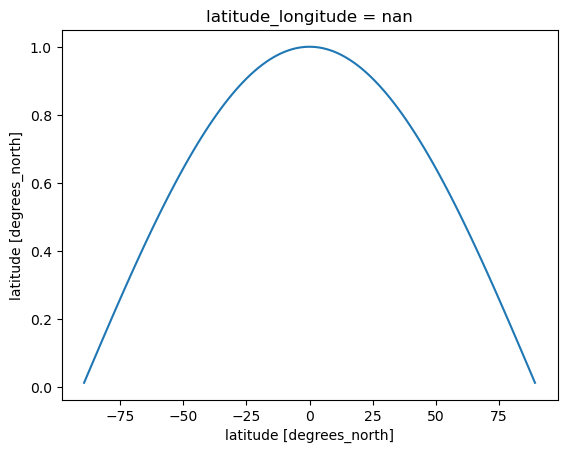

In [370]:
weights = np.cos(np.deg2rad(out.lat))
weights.plot()

In [371]:
test = out.co2.weighted(weights=weights).mean(('lat', 'lon'))

In [372]:
import matplotlib.pyplot as plt

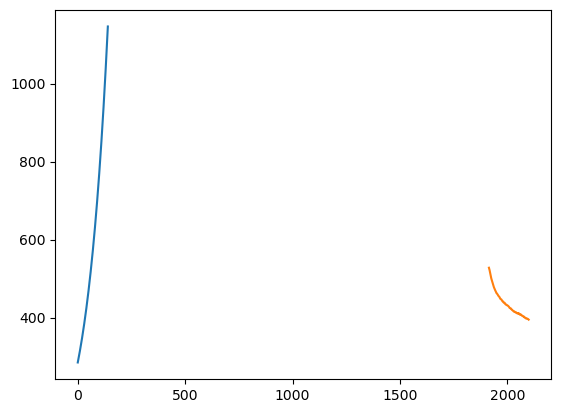

In [373]:
plt.plot(np.arange(0, 141, 1), calculate_1pctco2_concentration(284.7, 140))
plt.plot(test.time.dt.year, (test.mean('plev')*1e6).squeeze())

In [201]:
test.time.dt.year

<xarray.DataArray 'year' (time: 241)>
array([1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920,
       1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931,
       1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942,
       1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953,
       1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964,
       1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
       2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
       2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052,
       2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063,
       2064, 2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
       2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085,
       2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096,
       2097, 2098, 2099, 2100, 2101, 2102, 2103, 2104, 2105, 2106, 2107,
       2108, 2109, 2110, 2111, 2112, 2113, 2114, 2115, 2116, 2117, 2118,
       2119, 2120, 2121, 2122, 2123, 2124, 2125, 2126, 2127, 2128, 2129,
       2130, 2131, 2132, 2133, 2134, 2135, 2136, 2137, 2138, 2139, 2140,
       2141, 2142, 2143, 2144, 2145, 2146, 2147, 2148, 2149, 2150])
Coordinates:
  * time                (time) object 1910-06-01 00:00:00 ... 2150-06-01 00:0...
    latitude_longitude  float64 nan